# `skipna` test: Comparison with CDAT

https://github.com/xCDAT/xcdat/issues/582

Enable `skipna` parameter of xarray (https://docs.xarray.dev/en/stable/generated/xarray.DataArray.mean.html) in xcdat operations

## 1. Prepare sample input data

In [1]:
import xcdat as xc
import numpy as np

In [2]:
inputfile = "/Users/lee1043/Documents/Research/git/pcmdi_metrics_20230620_pcmdi/pcmdi_metrics/doc/jupyter/Demo/demo_data/CMIP5_demo_data/ts_Amon_ACCESS1-0_historical_r1i1p1_185001-200512.nc"
data_var = "ts"

In [3]:
ds = xc.open_dataset(inputfile).isel(time=slice(6, 8))

In [4]:
ds

<xarray.Dataset> Size: 231kB
Dimensions:    (time: 2, bnds: 2, lat: 145, lon: 192)
Coordinates:
  * lat        (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) object 16B 1850-07-16 12:00:00 1850-08-16 12:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 32B ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    ts         (time, lat, lon) float32 223kB ...
Attributes: (12/28)
    institution:            CSIRO (Commonwealth Scientific and Industrial Res...
    institute_id:           CSIRO-BOM
    experiment_id:          historical
    source:                 ACCESS1-0 2011. Atmosphere: AGCM v1.0 (N96 grid-p...
    model_id:               ACCESS1-0
    forcing:                GHG, Oz, SA, Sl, Vl, BC, OC, (GHG = CO2, N2O, CH4...
    ...                     ...
    table_id:               Table Amon (27 April 2011) 9c851218e3842df9a62ef3...
    title:                  ACCESS1-0 model output prepared for CMIP5 historical
    parent_experiment:      pre-industrial control
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.8.0

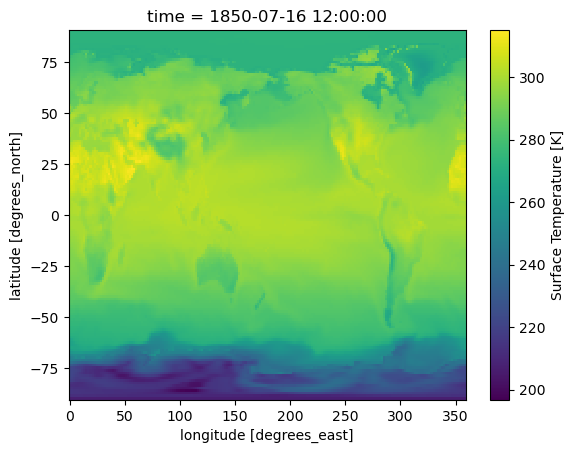

In [5]:
ds[data_var].isel(time=0).plot()

In [6]:
ds

<xarray.Dataset> Size: 231kB
Dimensions:    (time: 2, bnds: 2, lat: 145, lon: 192)
Coordinates:
  * lat        (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * time       (time) object 16B 1850-07-16 12:00:00 1850-08-16 12:00:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 32B ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    ts         (time, lat, lon) float32 223kB ...
Attributes: (12/28)
    institution:            CSIRO (Commonwealth Scientific and Industrial Res...
    institute_id:           CSIRO-BOM
    experiment_id:          historical
    source:                 ACCESS1-0 2011. Atmosphere: AGCM v1.0 (N96 grid-p...
    model_id:               ACCESS1-0
    forcing:                GHG, Oz, SA, Sl, Vl, BC, OC, (GHG = CO2, N2O, CH4...
    ...                     ...
    table_id:               Table Amon (27 April 2011) 9c851218e3842df9a62ef3...
    title:                  ACCESS1-0 model output prepared for CMIP5 historical
    parent_experiment:      pre-industrial control
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.8.0

In [7]:
ds.isel(time=0).spatial.average(data_var)[data_var].item()

290.01625076385056

### Inject NaN values in time step 0

In [8]:
da = ds[data_var].isel(time=0).copy()

# Define the latitude and longitude ranges
lat_range = (20, 70)
lon_range = (210, 320)

# Create masks for the latitude and longitude ranges
lat_mask = (da.lat >= lat_range[0]) & (da.lat <= lat_range[1])
lon_mask = (da.lon >= lon_range[0]) & (da.lon <= lon_range[1])

# Use broadcasting to apply the masks across the array dimensions
da.values[np.ix_(lat_mask, lon_mask)] = np.nan

# Update the original dataset with the modified data array
ds[data_var].values[0] = da

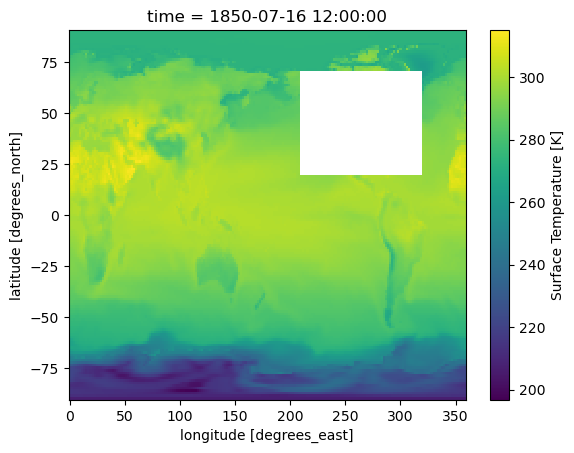

In [9]:
ds[data_var].isel(time=0).plot()

In [10]:
ds.to_netcdf("modified_sample_data.nc")

## CDAT test

In [11]:
import cdms2
import cdutil

In [12]:
f = cdms2.open("modified_sample_data.nc")
d = f("ts")

In [13]:
d_avg_time = cdutil.averager(d, axis='0')

In [14]:
d_avg_time.shape

(145, 192)

In [15]:
import xarray as xr

In [16]:
# Create the xarray Dataset
ds_avg_time = xr.Dataset(
    {
        data_var: (["lat", "lon"], d_avg_time)
    },
    coords={
        "lat": ds.lat,
        "lon": ds.lon
    }
)

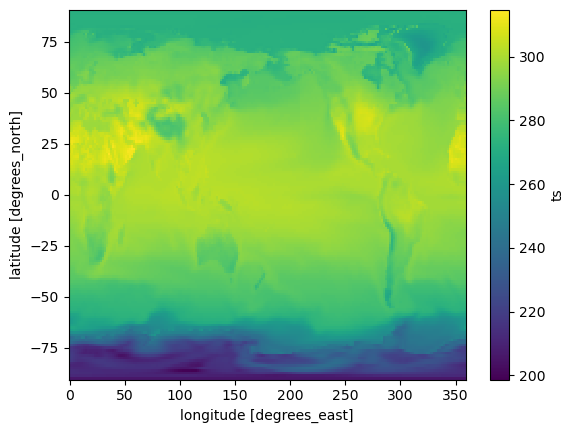

In [17]:
ds_avg_time[data_var].plot()

In [18]:
d_avg_space = cdutil.averager(d, axis='xy')

In [19]:
d_avg_space.shape

(2,)

In [20]:
d_avg_space[0]

289.67768423438235

## 2. xCDAT Spatial Average

### Average operation (skipping NaN by default)

The calculated number is consistent to the above number.

In [21]:
ds.isel(time=0).spatial.average(data_var)[data_var].item()

289.6776842343783

## 3. xCDAT Temporal average

### Average operation (skipping NaN by default)

The calculated fields are consistent to each other.

In [22]:
ds_avg_time_xcdat = ds.temporal.average(data_var)

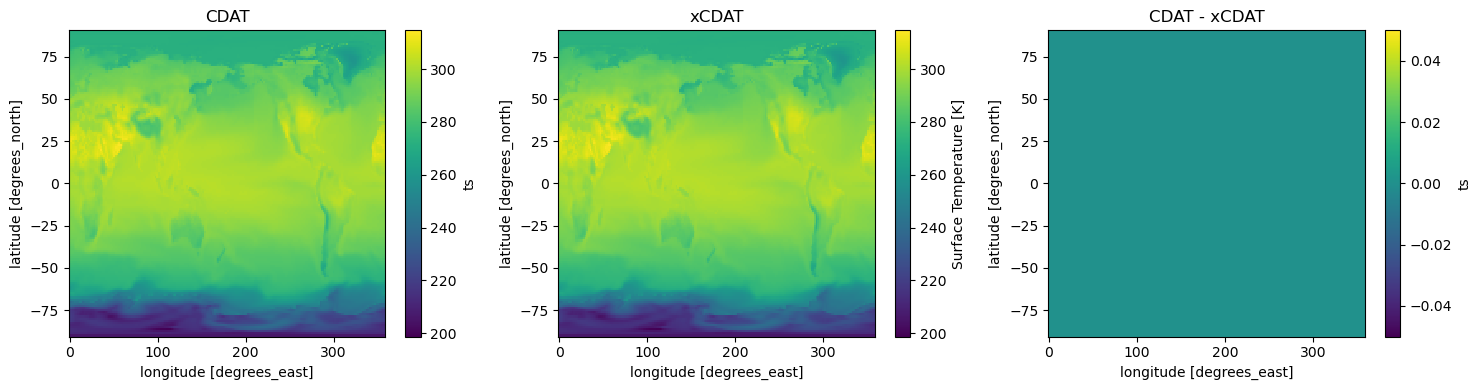

In [23]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot the first dataset
ds_avg_time[data_var].plot(ax=axes[0])
axes[0].set_title("CDAT")
ds_avg_time_xcdat[data_var].plot(ax=axes[1])
axes[1].set_title("xCDAT")
(ds_avg_time[data_var] - ds_avg_time_xcdat[data_var]).plot(ax=axes[2])
axes[2].set_title("CDAT - xCDAT")

fig.tight_layout()